# Large spatial scale extraction of velocity fields

If your goal requires you to examine velocity fields over large spatial areas, especially if you require few epochs, then it makes sense to use the Zarr store optimized for this type of operation.

The Greenland Zarr store most suited to this analysis is called `greenland_multisource_velocity_spatial.zarr` whilst the Antarctic equivalent is called `antarctica_multisource_velocity_spatial.zarr` and their equivalent URLs are:


In [1]:
# Greenland URL
greenland_url = "https://data.source.coop/uos-shiver/greenland/greenland_multisource_velocity_spatial.zarr"

# Antarctica URL
antarctica_url = "https://data.source.coop/uos-shiver/antarctica/antarctica_multisource_velocity_spatial.zarr"


These are `OME-Zarr` stores, which are analagous to Cloud Optimized Geotiffs for Zarr. They contain multiple copies of the velocity data at varying spatial resolutions. At the lowest level (group 0), the resolution is 200 m, whereas at the highest level (group 4 for Greenland and group 5 for Antarctica) the resolution is 3200 m for Greenland and 6400 m for Antarctica. If your analysis does not require the highest spatial resolution, you can save yourself significant resources by using one of the lower resolution layers.

In this example, we will visualise a large-scale velocity field of Greenland. Since plots (even those produced at a high dpi and viewed on a high spec monitor) are lower resolution than our data, it is a waste of resources to use the full resolution layer. Therefore, we will use lowest resolution layer, which we can do simply by specify the group number in `xr.open_zarr`.

In [2]:
import matplotlib.pyplot as plt
import zarr
import xarray as xr

# Load the lower spatial resolution layer lazily
ds = xr.open_zarr(greenland_url, group="4", consolidated=True)

We can filter the Zarr to target a particular Contributing Dataset. Since we want a relatively complete velocity field for this example, we will visualise the most recent `MEaSUREs_annual` velocity field. 

In [3]:
# Identify only measures annual data
source_mask = (ds['data_source'] == 'MEaSUREs_annual').compute()

# Apply the mask to the lazy time array
measures_times = ds.time[source_mask]

# 4. Select the last (most recent) matching epoch
latest_time = measures_times[-1]

# Slice the lazy dataset for the 'speed' variable and compute (download) it
speed_data_local = ds['speed'].sel(time=latest_time).compute()

Then plot the velocity field.

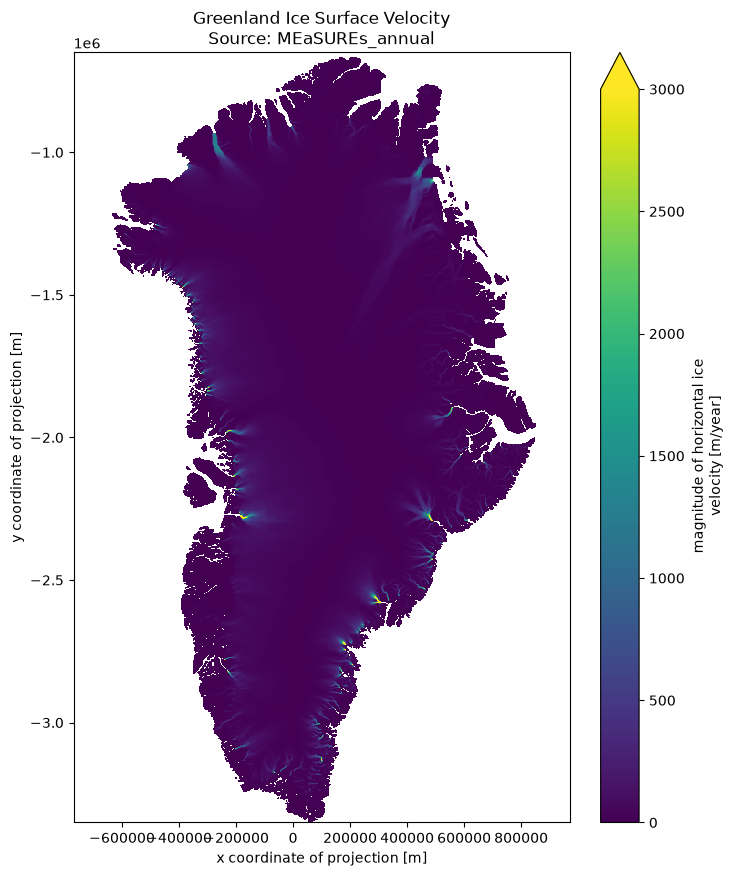

In [4]:
# Plot the full ice sheet
plt.figure(figsize=(8, 10))
speed_data_local.plot(cmap="viridis", vmin=0, vmax=3000)
plt.title(f"Greenland Ice Surface Velocity\nSource: MEaSUREs_annual")
plt.axis("equal")
plt.show()

It is quite common to require closer examination of small regions. In this case, it makes sense to use one of the higher resolution OME-Zarr groups, or even the highest resolution group. 

Let's take a closer look at the velocity field just north of Jakobshavn Isbrae in west Greenland, containing the termini of Sermeq Kujalleq, Sermeq Avannarleq, Kangilernata Sermia and Eqip Sermia.

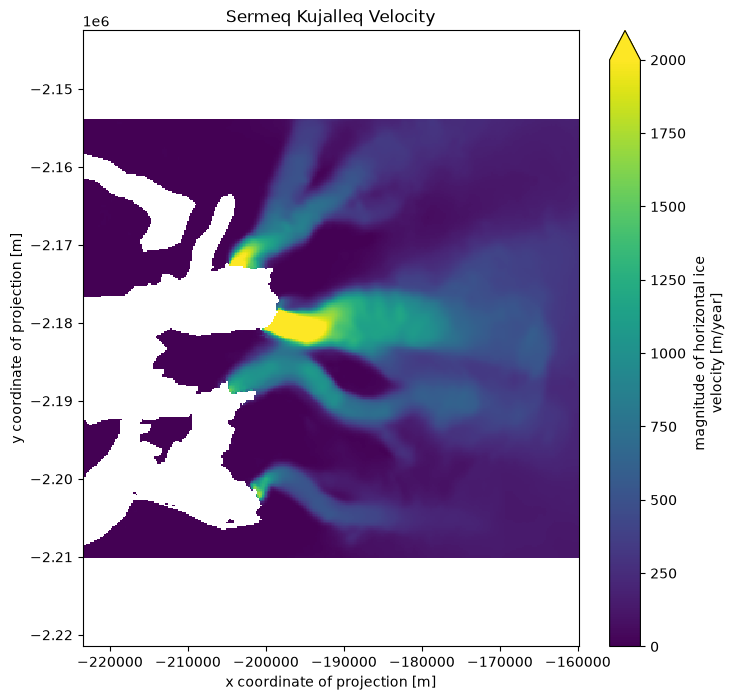

In [5]:
from pyproj import Transformer  

# Load the higher spatial resolution layer lazily
ds_hr = xr.open_zarr(greenland_url, group="0", consolidated=True)

# Convert Geographic coordinates (lon/lat) to Polar Stereographic (EPSG:3413)
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3413", always_xy=True)
lon_top_left, lat_top_left = -50.9249, 70.2013
lon_bot_right, lat_bot_right = -49.1396, 69.7488
xmin, ymax = transformer.transform(lon_top_left, lat_top_left)
xmax, ymin = transformer.transform(lon_bot_right, lat_bot_right)

# Find the most recent MEaSUREs_annual epoch
source_mask = (ds_hr['data_source'] == 'MEaSUREs_annual').compute()
latest_time = ds_hr.time[source_mask][-1]

# Handle Y-axis orientation for slicing
y_slice = slice(ymax, ymin) if ds_hr.y[0] > ds_hr.y[-1] else slice(ymin, ymax)

# Crop time and space lazily, then download the target area
sermeq_map = ds_hr['speed'].sel(
    time=latest_time,
    x=slice(xmin, xmax), 
    y=y_slice
).compute() 

# 6. Plot and Save
plt.figure(figsize=(8, 8))
sermeq_map.plot(cmap="viridis", vmin=0, vmax=2000)
plt.title("Sermeq Kujalleq Velocity")
plt.axis("equal")
plt.show()

### Calculating speed change

One major benefit of having large-scale temporally-resolved velocity fields is the ability to explore changes in speed over large areas and time periods. With these Zarr stores, we can relatively easily reproduce observed changes in speed around Antarctica presented in Rignot et al. (2022).

Extracting full bounds from Group 0...
Processing Group 5...
Processing subplots using Zarr group 2...


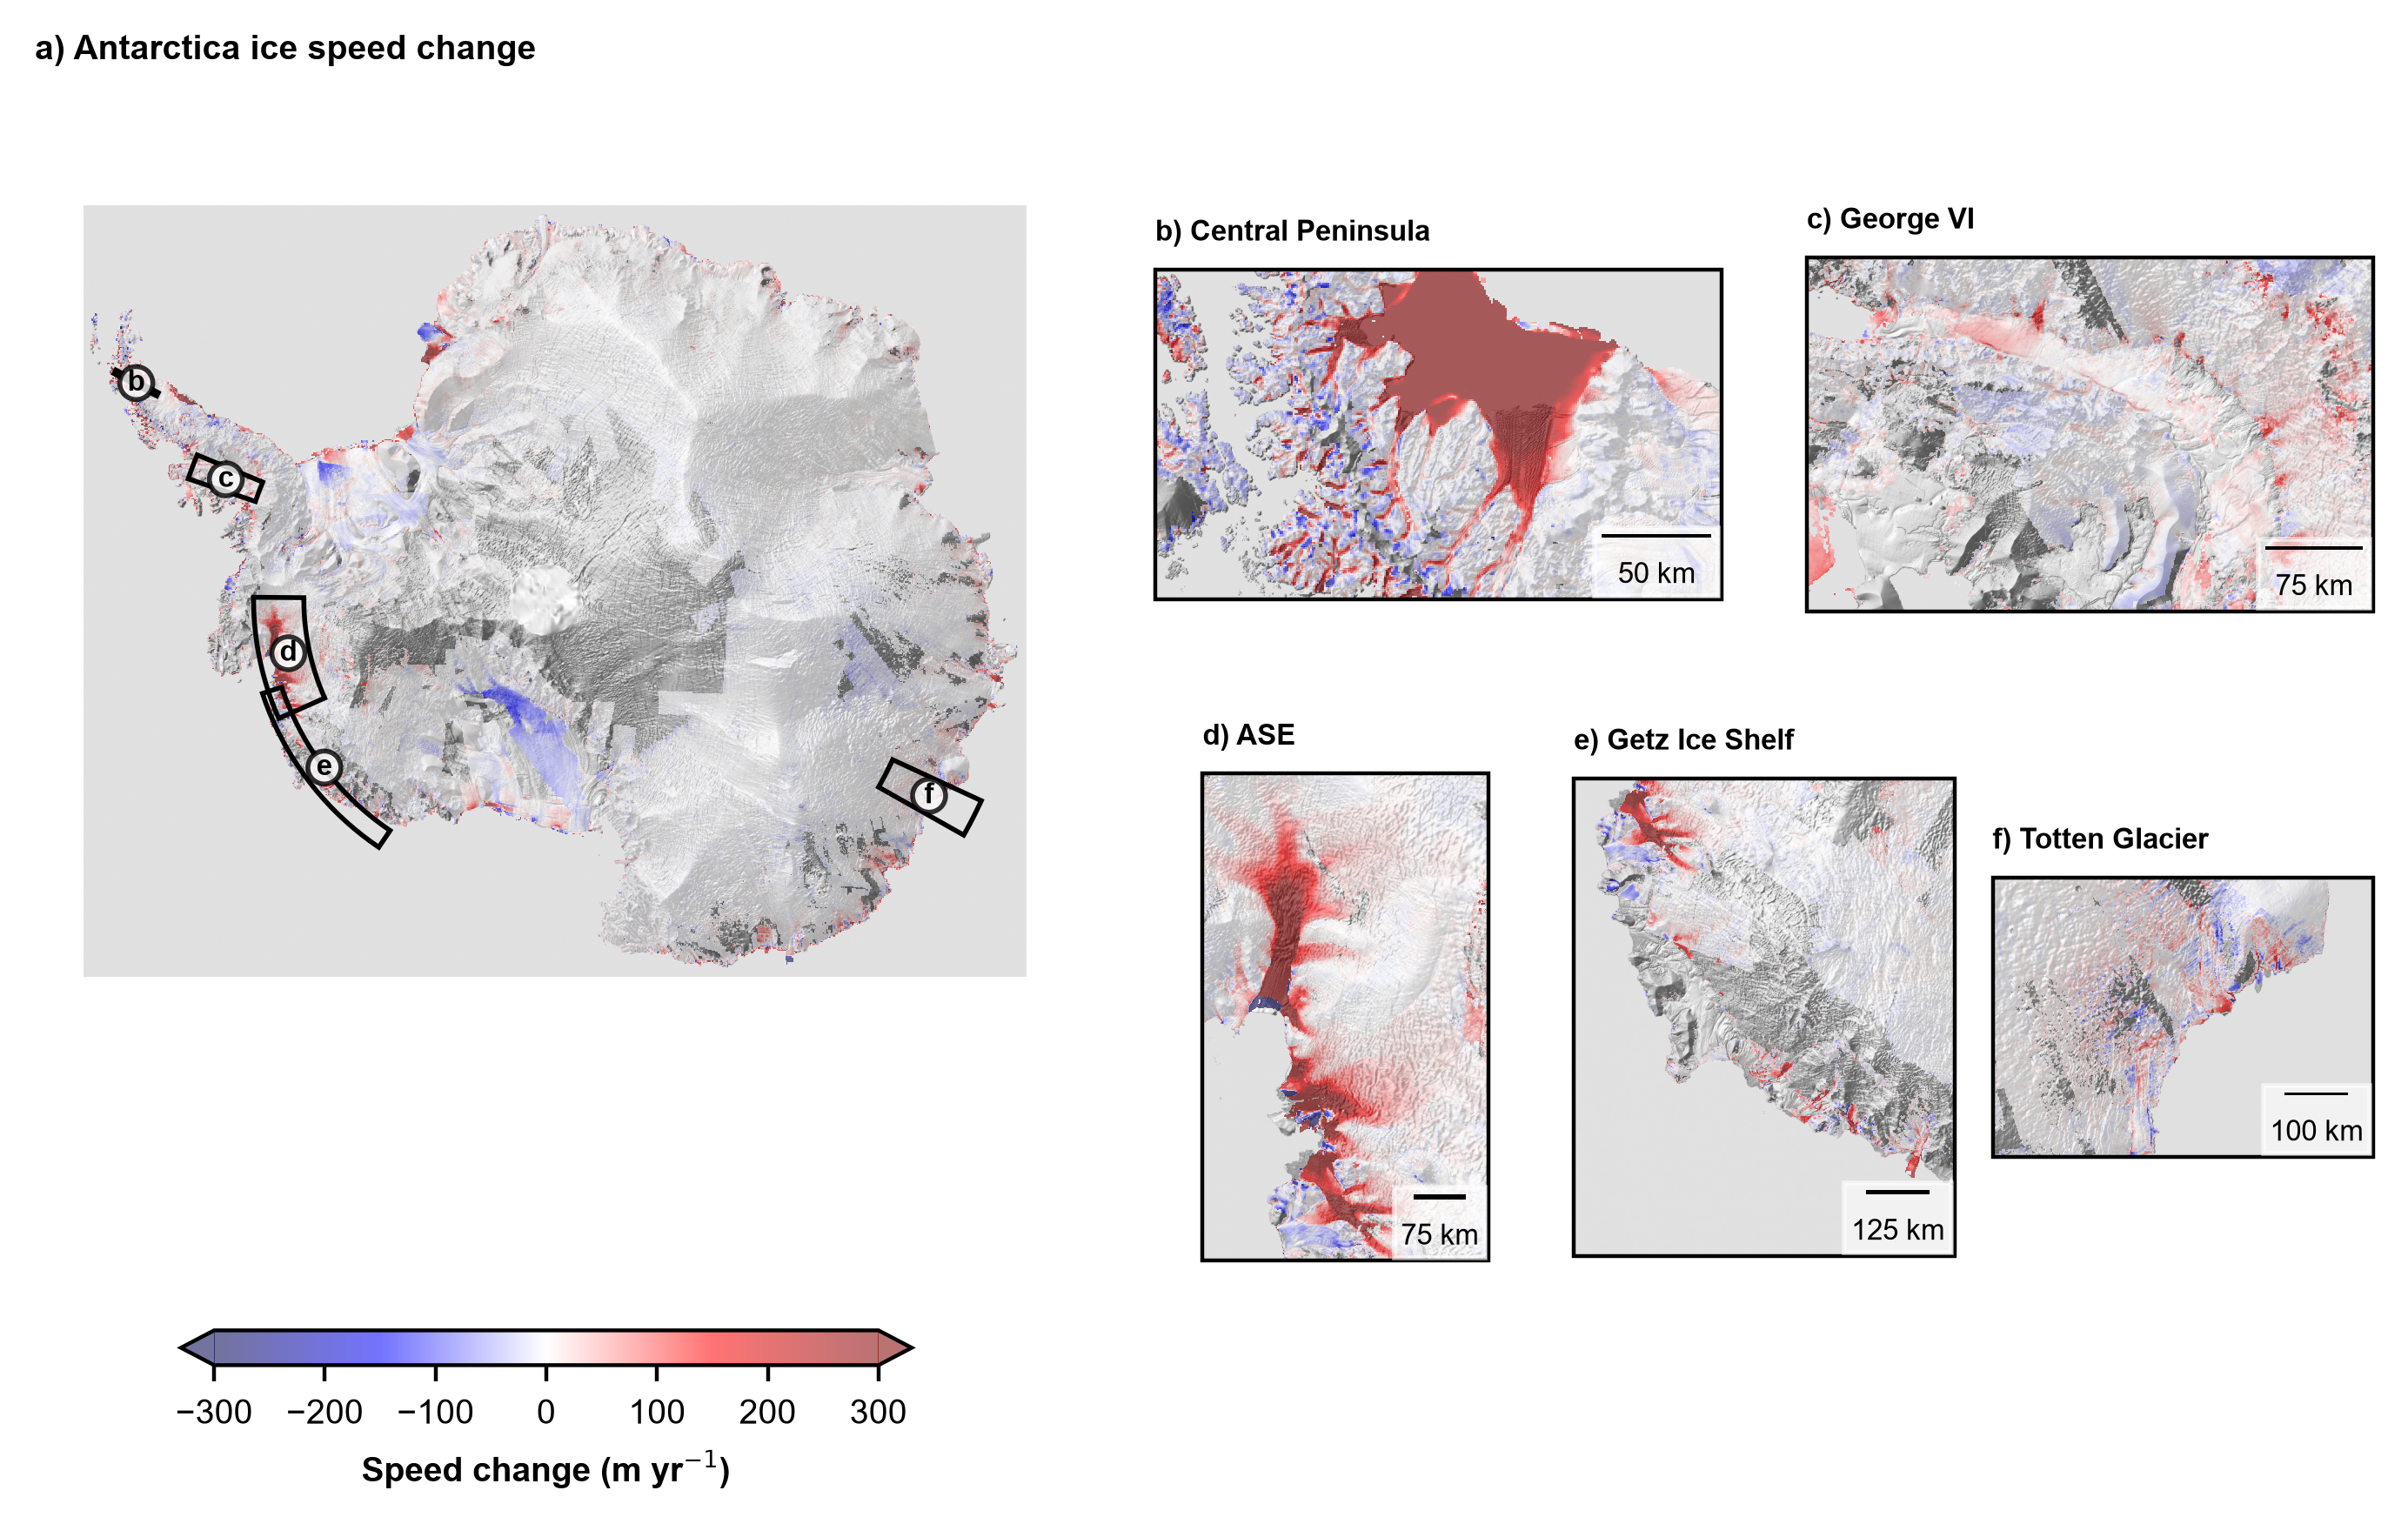

In [8]:
import numpy as np
import xarray as xr
import rioxarray as rxr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LightSource
from matplotlib.patches import Polygon
from matplotlib_scalebar.scalebar import ScaleBar
import cartopy.crs as ccrs
from pyproj import Transformer

# ==========================================
# 1. Configuration & Input Setup
# ==========================================
antarctica_url = "https://data.source.coop/uos-shiver/antarctica/antarctica_multisource_velocity_spatial.zarr"
dem_1km_path = r"/no/one/wants/to/see/my/directory/structure/REMA_1km_dem_filled.tif"
dem_200m_path = r"/no/one/wants/to/see/my/directory/structure/REMA_200m_dem_filled.tif"

# Define CRS
CRS_3031 = ccrs.SouthPolarStereo()
proj_transformer = Transformer.from_crs("EPSG:4326", "EPSG:3031", always_xy=True)

# Define regions for subplots
regions = {
    "b": {"name": "Central Peninsula", "coords": [-64.2506, -61.9245, -66.7136, -62.3837]},
    "c": {"name": "George VI", "coords": [-69.918, -67.481, -73.633, -71.344]},
    "d": {"name": "ASE", "coords": [-74.384, -89.529, -77.041, -113.937]},
    "e": {"name": "Getz Ice Shelf", "coords": [-74.056, -108.288, -75.121, -145.912]},
    "f": {"name": "Totten Glacier", "coords": [-69.733, 114.806, -64.687, 119.426]},
}

# ==========================================
# 2. Helper Functions
# ==========================================
def get_polygon_3031(lat1, lon1, lat2, lon2, n_samples=20):
    lats = np.concatenate([
        np.linspace(lat1, lat1, n_samples),
        np.linspace(lat1, lat2, n_samples),
        np.linspace(lat2, lat2, n_samples),
        np.linspace(lat2, lat1, n_samples)
    ])
    lons = np.concatenate([
        np.linspace(lon1, lon2, n_samples),
        np.linspace(lon2, lon2, n_samples),
        np.linspace(lon2, lon1, n_samples),
        np.linspace(lon1, lon1, n_samples)
    ])
    x, y = proj_transformer.transform(lons, lats)
    return np.column_stack([x, y])

def compute_speed_change(ds):
    source_mask = (ds['data_source'] == 'MEaSUREs_multiyear').compute()
    measures_times = ds.time[source_mask]
    
    speed_first = ds['speed'].sel(time=measures_times[0]).compute()
    speed_latest = ds['speed'].sel(time=measures_times[-1]).compute()
    
    return speed_latest - speed_first

def create_hillshade(dem_raster):
    ls = LightSource(azdeg=315, altdeg=45)
    dem_filled = np.nan_to_num(dem_raster.values, nan=0)
    return ls.hillshade(dem_filled, vert_exag=2)

# ==========================================
# 3. Data Processing - Overview Map
# ==========================================
print("Extracting full bounds from Group 0...")
ds_g0 = xr.open_zarr(antarctica_url, group="0", consolidated=True)
full_x_min, full_x_max = ds_g0.x.min().item(), ds_g0.x.max().item()
full_y_min, full_y_max = ds_g0.y.min().item(), ds_g0.y.max().item()

print("Processing Group 5...")
ds_g5 = xr.open_zarr(antarctica_url, group="5", consolidated=True)
speed_change_g5 = compute_speed_change(ds_g5)

dem_1km = rxr.open_rasterio(dem_1km_path, masked=True).squeeze()
dem_1km_hillshade = create_hillshade(dem_1km)
extent_1km = [dem_1km.x.min().item(), dem_1km.x.max().item(), 
              dem_1km.y.min().item(), dem_1km.y.max().item()]

# ==========================================
# 4. Figure Layout Initialization
# ==========================================
plt.rcParams.update({'font.sans-serif': 'Arial', 'font.size': 7})
fig = plt.figure(figsize=(7, 5), dpi=400)

gs_left = gridspec.GridSpec(1, 1, left=0.02, right=0.44, bottom=0.25, top=0.95)
gs_right_top = gridspec.GridSpec(1, 2, left=0.48, right=0.98, bottom=0.54, top=0.85, wspace=0.15)
gs_right_bot = gridspec.GridSpec(1, 3, left=0.48, right=0.98, bottom=0.22, top=0.50, wspace=0.10)

ax_main = fig.add_subplot(gs_left[0], projection=CRS_3031)

# ==========================================
# 5. Plot overview
# ==========================================
ax_main.imshow(dem_1km_hillshade, cmap='gray', origin='upper', extent=extent_1km, alpha=0.7)

im = speed_change_g5.plot.imshow(
    ax=ax_main, cmap="seismic", vmin=-300, vmax=300, alpha=0.55,
    add_colorbar=False, transform=CRS_3031
)

# Ensure panels fits everything in
x_center = (full_x_max + full_x_min) / 2.0
y_center = (full_y_max + full_y_min) / 2.0
max_range = max(full_x_max - full_x_min, full_y_max - full_y_min) # Find the largest spatial dimension (width or height)
zoom_buffer = max_range * 0.02   # Add a 2% buffer to "zoom out" slightly 
ax_main.set_xlim(x_center - (max_range/2) - zoom_buffer, x_center + (max_range/2) + zoom_buffer)
ax_main.set_ylim(y_center - (max_range/2) - zoom_buffer, y_center + (max_range/2) + zoom_buffer)

ax_main.set_title("a) Antarctica ice speed change", fontsize=7, fontweight='bold', loc='left')

# Remove the bounding box from the main panel
try:
    ax_main.spines['geo'].set_visible(False)
except KeyError:
    ax_main.outline_patch.set_visible(False)

# Draw and label bounding boxes
region_polygons = {}
for key, info in regions.items():
    poly_pts = get_polygon_3031(*info["coords"])
    region_polygons[key] = poly_pts
    
    rect = Polygon(poly_pts, closed=True, linewidth=1.0, edgecolor='black', facecolor='none', zorder=10)
    ax_main.add_patch(rect)
    
    centroid_x, centroid_y = poly_pts[:, 0].mean(), poly_pts[:, 1].mean()
    ax_main.text(centroid_x, centroid_y, key, fontsize=6, fontweight='bold',
                 color='black', bbox=dict(boxstyle='circle,pad=0.1', facecolor='white', edgecolor='black', alpha=0.8),
                 ha='center', va='center', zorder=11)

# ==========================================
# 6. Process & plot subpanels (b-f)
# ==========================================
print("Processing subplots using Zarr group 2...")
ds_g2 = xr.open_zarr(antarctica_url, group="2", consolidated=True)
dem_200m = rxr.open_rasterio(dem_200m_path, masked=True).squeeze()

subplot_slots = [
    gs_right_top[0, 0], # b
    gs_right_top[0, 1], # c
    gs_right_bot[0, 0], # d
    gs_right_bot[0, 1], # e
    gs_right_bot[0, 2], # f
]

for idx, (key, info) in enumerate(regions.items()):
    ax_sub = fig.add_subplot(subplot_slots[idx], projection=CRS_3031)
    
    pts = region_polygons[key]
    xmin, xmax = pts[:, 0].min(), pts[:, 0].max()
    ymin, ymax = pts[:, 1].min(), pts[:, 1].max()
    
    dem_sub = dem_200m.rio.clip_box(minx=xmin, miny=ymin, maxx=xmax, maxy=ymax)
    hillshade_sub = create_hillshade(dem_sub)
    sub_extent = [dem_sub.x.min().item(), dem_sub.x.max().item(),
                  dem_sub.y.min().item(), dem_sub.y.max().item()]
    
    ds_g2_sub = ds_g2.sel(x=slice(xmin, xmax), y=slice(ymax, ymin))
    if ds_g2_sub.x.size == 0 or ds_g2_sub.y.size == 0:
        ds_g2_sub = ds_g2.sel(x=slice(xmin, xmax), y=slice(ymin, ymax))
        
    speed_change_g2 = compute_speed_change(ds_g2_sub)
    
    ax_sub.imshow(hillshade_sub, cmap='gray', origin='upper', extent=sub_extent, alpha=0.7)
    speed_change_g2.plot.imshow(
        ax=ax_sub, cmap="seismic", vmin=-300, vmax=300, alpha=0.6,
        add_colorbar=False, transform=CRS_3031
    )
    
    ax_sub.set_extent([xmin, xmax, ymin, ymax], crs=CRS_3031)
    ax_sub.set_title(f"{key}) {info['name']}", fontsize=6, fontweight='bold', loc='left')
    
    scalebar = ScaleBar(1, units="m", location="lower right", box_alpha=0.6, font_properties={'size': 6})
    ax_sub.add_artist(scalebar)

# ==========================================
# 7. Global Colorbar & Output
# ==========================================
cax = fig.add_axes([0.08, 0.16, 0.30, 0.02])
cbar = fig.colorbar(im, cax=cax, orientation='horizontal', extend='both')
cbar.set_label('Speed change (m yr$^{-1}$)', fontsize=7, fontweight='bold')
plt.show()